# 04: Background Variance Analysis
Phân tích phương sai pixel để phân biệt giữa nền đường trống và vật thể (xe ô tô), dựa trên code từ `backend/core_cv/segmentation.py`.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import glob

# --- PHẦN 1: ĐỊNH NGHĨA LOGIC (Đã tách khỏi backend) ---

def apply_preprocessing(image):
    resized = cv2.resize(image, (64, 128))
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    equalized = clahe.apply(gray)
    blurred = cv2.GaussianBlur(equalized, (3, 3), 0)
    return blurred

def is_flat_background(gray_image, variance_threshold=150):
    variance = np.var(gray_image)
    return (variance < variance_threshold), variance


### 1. Tại sao dùng Phương sai (Variance)?
Nhựa đường trống thường có kết cấu rất mịn, dẫn đến phương sai cường độ pixel thấp. Xe ô tô có nhiều chi tiết, màu sắc khác nhau nên phương sai cao.

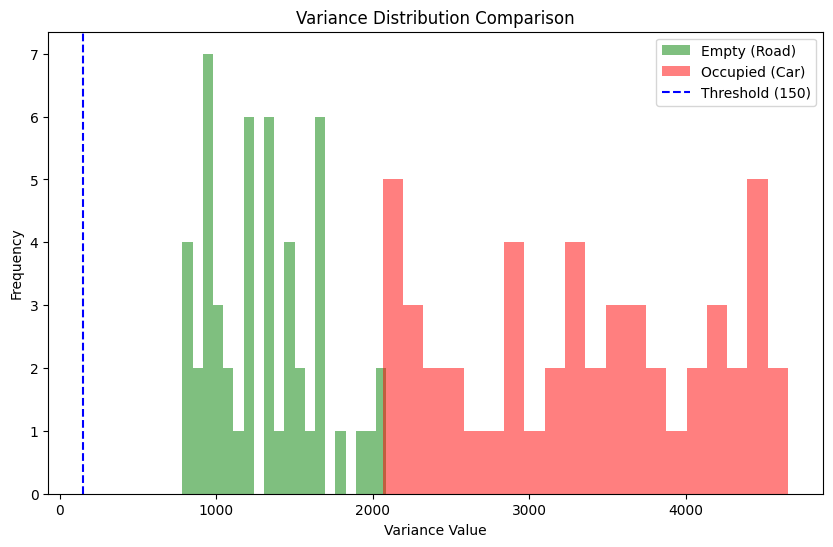

In [2]:
def calculate_variance_samples(folder_path):
    variances = []
    paths = glob.glob(os.path.join(folder_path, '*.jpg'))[:50] # Lấy 50 mẫu đầu tiên
    
    for p in paths:
        img = cv2.imread(p)
        if img is not None:
            pre = apply_preprocessing(img)
            _, var = is_flat_background(pre)
            variances.append(var)
    return variances

occ_vars = calculate_variance_samples('../backend/data/train/occupied')
emp_vars = calculate_variance_samples('../backend/data/train/empty')

plt.figure(figsize=(10, 6))
plt.hist(emp_vars, bins=20, alpha=0.5, label='Empty (Road)', color='green')
plt.hist(occ_vars, bins=20, alpha=0.5, label='Occupied (Car)', color='red')
plt.axvline(x=150, color='blue', linestyle='--', label='Threshold (150)')
plt.title("Variance Distribution Comparison")
plt.xlabel("Variance Value")
plt.ylabel("Frequency")
plt.legend()
plt.show()

### 2. Kết luận
Dựa trên biểu đồ, chúng ta có thể thấy ngưỡng 120-150 là hợp lý để tách biệt phần lớn các bãi trống mà không cần dùng đến SVM, giúp tối ưu hiệu năng.